In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#loading the datasets

orders = pd.read_csv("List of Orders.csv")
details = pd.read_csv("Order Details.csv")
targets=pd.read_csv("Sales target.csv")

print(orders.head())
print(details.head())
print(targets.head())

  Order ID  Order Date CustomerName           State       City
0  B-25601  01-04-2018       Bharat         Gujarat  Ahmedabad
1  B-25602  01-04-2018        Pearl     Maharashtra       Pune
2  B-25603  03-04-2018        Jahan  Madhya Pradesh     Bhopal
3  B-25604  03-04-2018       Divsha       Rajasthan     Jaipur
4  B-25605  05-04-2018      Kasheen     West Bengal    Kolkata
  Order ID  Amount  Profit  Quantity     Category      Sub-Category
0  B-25601  1275.0 -1148.0         7    Furniture         Bookcases
1  B-25601    66.0   -12.0         5     Clothing             Stole
2  B-25601     8.0    -2.0         3     Clothing       Hankerchief
3  B-25601    80.0   -56.0         4  Electronics  Electronic Games
4  B-25602   168.0  -111.0         2  Electronics            Phones
  Month of Order Date   Category   Target
0              Apr-18  Furniture  10400.0
1              May-18  Furniture  10500.0
2              Jun-18  Furniture  10600.0
3              Jul-18  Furniture  10800.0
4   

In [5]:
print(orders.info())
print(details.info())
print(targets.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 22.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      1500 non-null   object 
 1   Amount        1500 non-null   float64
 2   Profit        1500 non-null   float64
 3   Quantity      1500 non-null   int64  
 4   Category      1500 non-null   object 
 5   Sub-Category  1500 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 70.4+ KB
None
<class 'pandas.core.frame.DataFrame'>


In [6]:
print(orders.isnull().sum())
print(details.isnull().sum())

Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
dtype: int64


In [7]:
print(orders.duplicated().sum())
print(details.duplicated().sum())

59
0


In [13]:
print(orders['Order Date'].head())

0    01-04-2018
1    01-04-2018
2    03-04-2018
3    03-04-2018
4    05-04-2018
Name: Order Date, dtype: object


In [15]:
# date conversion

orders['Order Date'] = pd.to_datetime(orders['Order Date'], dayfirst=True)

In [17]:
print(orders['Order ID'].nunique())
print(details['Order ID'].nunique())

500
500


In [19]:
orders = orders.dropna()
details = details.dropna()

orders = orders.drop_duplicates()
details = details.drop_duplicates()

In [21]:
df = pd.merge(orders, details, on='Order ID', how='inner')

In [23]:
print(df.shape)
print(df.head())

(1500, 10)
  Order ID Order Date CustomerName        State       City  Amount  Profit  \
0  B-25601 2018-04-01       Bharat      Gujarat  Ahmedabad  1275.0 -1148.0   
1  B-25601 2018-04-01       Bharat      Gujarat  Ahmedabad    66.0   -12.0   
2  B-25601 2018-04-01       Bharat      Gujarat  Ahmedabad     8.0    -2.0   
3  B-25601 2018-04-01       Bharat      Gujarat  Ahmedabad    80.0   -56.0   
4  B-25602 2018-04-01        Pearl  Maharashtra       Pune   168.0  -111.0   

   Quantity     Category      Sub-Category  
0         7    Furniture         Bookcases  
1         5     Clothing             Stole  
2         3     Clothing       Hankerchief  
3         4  Electronics  Electronic Games  
4         2  Electronics            Phones  


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1500 non-null   object        
 1   Order Date    1500 non-null   datetime64[ns]
 2   CustomerName  1500 non-null   object        
 3   State         1500 non-null   object        
 4   City          1500 non-null   object        
 5   Amount        1500 non-null   float64       
 6   Profit        1500 non-null   float64       
 7   Quantity      1500 non-null   int64         
 8   Category      1500 non-null   object        
 9   Sub-Category  1500 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 117.3+ KB


In [27]:

df.describe()

,Order Date,Amount,Profit,Quantity
count,1500,1500.000000,1500.000000,1500.000000
mean,2018-10-23 14:00:57.600000,287.668000,15.970000,3.743333
min,2018-04-01 00:00:00,4.000000,-1981.000000,1.000000
25%,2018-07-26 18:00:00,45.000000,-9.250000,2.000000
50%,2018-11-08 00:00:00,118.000000,9.000000,3.000000
75%,2019-01-27 00:00:00,322.000000,38.000000,5.000000
max,2019-03-31 00:00:00,5729.000000,1698.000000,14.000000
std,NaN,461.050488,169.140565,2.184942


In [29]:
print(df['Order ID'].nunique())
print(df['CustomerName'].nunique())

500
332


In [31]:
df['customer_name_clean'] = (
    df['CustomerName']
    .str.strip()          # remove spaces at start/end
    .str.lower()          # make lowercase
    .str.replace(r'\s+', ' ', regex=True)  # remove extra spaces
)

In [33]:
print("Original unique names:", df['CustomerName'].nunique())
print("Cleaned unique names:", df['customer_name_clean'].nunique())

Original unique names: 332
Cleaned unique names: 332


In [35]:
df['Customer_id'] = df['CustomerName'].astype('category').cat.codes

In [37]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['year_month'] = df['Order Date'].dt.to_period('M')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1500 non-null   object        
 1   Order Date           1500 non-null   datetime64[ns]
 2   CustomerName         1500 non-null   object        
 3   State                1500 non-null   object        
 4   City                 1500 non-null   object        
 5   Amount               1500 non-null   float64       
 6   Profit               1500 non-null   float64       
 7   Quantity             1500 non-null   int64         
 8   Category             1500 non-null   object        
 9   Sub-Category         1500 non-null   object        
 10  customer_name_clean  1500 non-null   object        
 11  Customer_id          1500 non-null   int16         
 12  year                 1500 non-null   int32         
 13  month                1500 non-nul

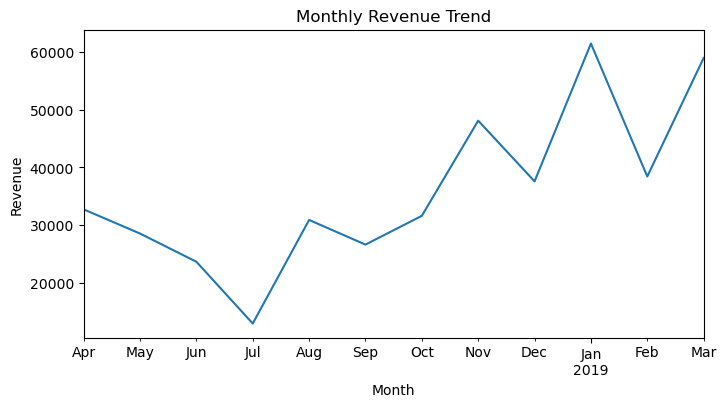

In [41]:
monthly_revenue = df.groupby('year_month')['Amount'].sum()
plt.figure(figsize=(8,4))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


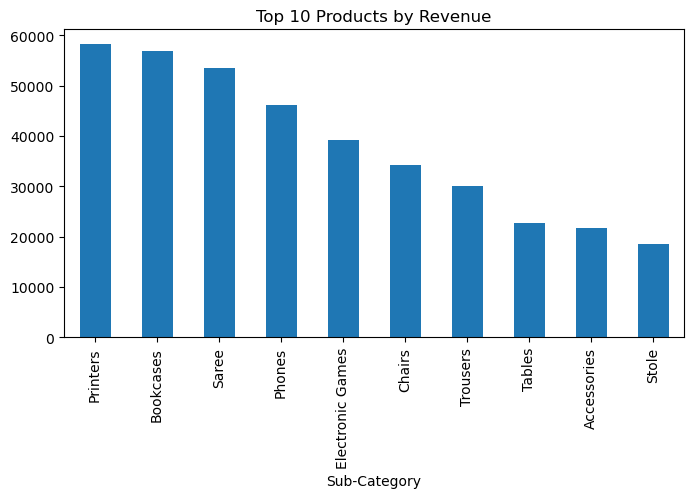

In [43]:
top_products = df.groupby('Sub-Category')['Amount'] \
.sum() \
.sort_values(ascending=False) \
.head(10)
plt.figure(figsize=(8,4))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.show()


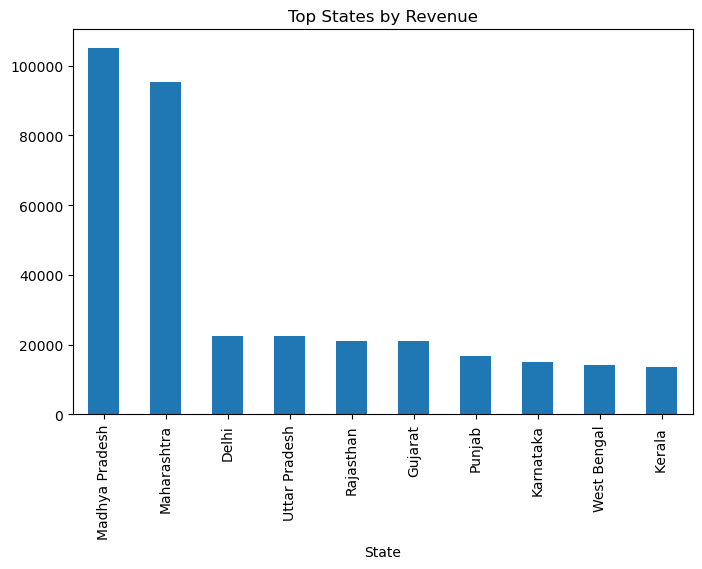

In [45]:
country_sales = df.groupby('State')['Amount'] \
.sum() \
.sort_values(ascending=False) \
.head(10)
plt.figure(figsize=(8,5))
country_sales.plot(kind='bar')
plt.title("Top States by Revenue")
plt.show()


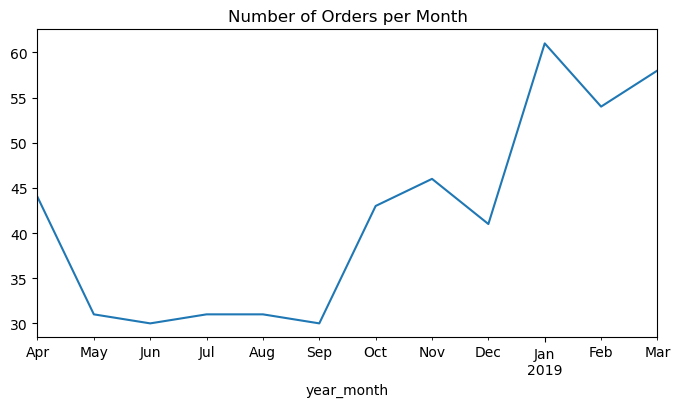

In [47]:
orders = df.groupby('year_month')['Order ID'].nunique()
plt.figure(figsize=(8,4))
orders.plot()
plt.title("Number of Orders per Month")
plt.show()


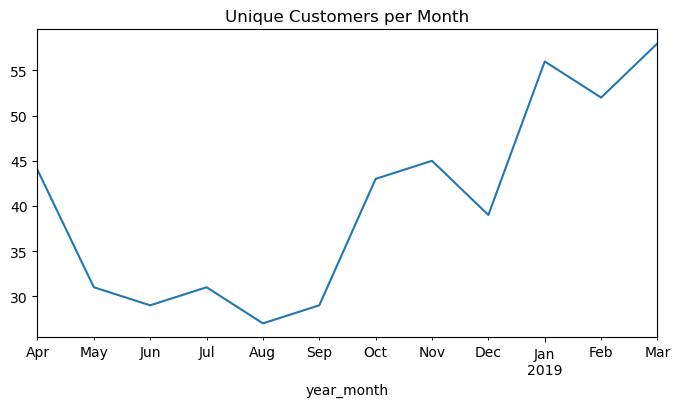

In [49]:
customers = df.groupby('year_month')['Customer_id'].nunique()
plt.figure(figsize=(8,4))
customers.plot()
plt.title("Unique Customers per Month")
plt.show()


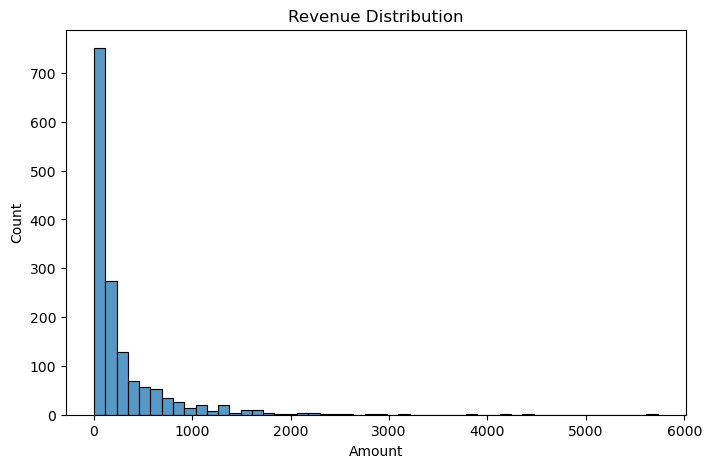

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Revenue Distribution")
plt.show()

In [53]:
df['cohort_month'] = df.groupby('CustomerName')['Order Date'] \
                       .transform('min') \
                       .dt.to_period('M')

In [55]:
df['OrderMonth'] = df['Order Date'].dt.to_period('M')

df['CohortIndex'] = (df['OrderMonth'] - df['cohort_month']).apply(lambda x: x.n)

In [57]:
cohort_data = df.groupby(['cohort_month', 'CohortIndex'])['Customer_id'].nunique().reset_index()

In [59]:
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='CohortIndex', values='Customer_id')

In [61]:
cohort_size = cohort_pivot.iloc[:, 0]

retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

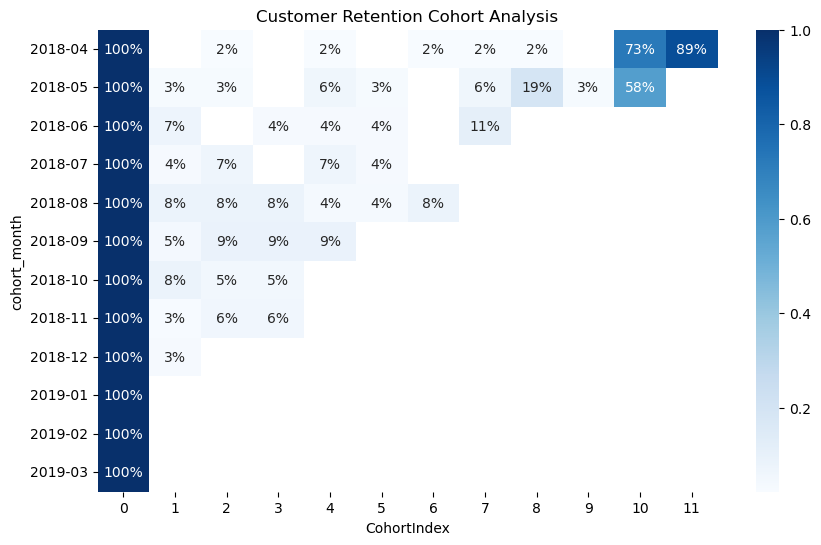

In [63]:

plt.figure(figsize=(10,6))
sns.heatmap(retention_matrix, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention Cohort Analysis")
plt.show()

In [70]:
df.to_csv("CleanedData.csv", index=False)
retention_matrix.to_csv("CohortRetention.csv")